# Imports

In [21]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA

# USER CONFIGURATION -- BC_HP_10x

In [ ]:
# =============================================================================
# USER CONFIGURATION -- BC_HP_10x
# =============================================================================

SPACROSS_ROOT = Path(r"/home/dal875013/work/projects/mocha/methods/spacross/SpaCross")

DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/BC_HP_10x/data")

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/bc_hp_spacross")

CONFIG_PATH = SPACROSS_ROOT / "Config" / "DLPFC.yaml"

ALL_BC_HP_SAMPLES = [
    "GSM6592049_M2",
    "GSM6592050_M3",
    "GSM6592051_M4",
    "GSM6592052_M5",
    "GSM6592053_M6",
    "GSM6592055_M8",
    "GSM6592059_M13",
    "GSM6592060_M14",
    "GSM6592061_M15",
    "GSM6592062_M16",
    "GSM6592054_M7",
    "GSM6592057_M10",
    "GSM6592056_M9",
    "GSM6592058_M11",
]

SAMPLES_TO_RUN = "all"

METHOD_NAME = "SpaCross"
CLUST_METHOD = "mclust"
NUM_RUNS = 1

# BC_HP observed classes per sample
BC_HP_NUM_CLUSTERS = 6

GT_LABEL_COL = "z"
SPATIAL_KEY = "S"


# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available -- using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU -- falling back to CPU")
    return dev


def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w", encoding="utf-8"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


def resolve_samples(selector) -> list:
    if selector is None or selector == "all":
        return list(ALL_BC_HP_SAMPLES)
    if isinstance(selector, str):
        return [selector]
    if isinstance(selector, (list, tuple)):
        return [str(s) for s in selector]
    raise ValueError(f"Unrecognized SAMPLES_TO_RUN value: {selector!r}")

# Data loading -- BC_HP-specific

In [23]:
# =============================================================================
# Data loading -- BC_HP-specific
# =============================================================================
def load_bc_hp_sample(config: dict, sample_id: str, tools_mod):
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")

    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")

    if GT_LABEL_COL not in adata.obs.columns:
        raise KeyError(
            f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
            f"Available: {list(adata.obs.columns)}"
        )

    adata.obs["layer_guess"] = adata.obs[GT_LABEL_COL].astype(object)

    gt_vals = adata.obs["layer_guess"]
    n_labeled = gt_vals.notna().sum()
    uniq_labels = sorted([str(x) for x in gt_vals.dropna().unique()])

    logging.info(
        f"  [DIAG] Using GT column '{GT_LABEL_COL}' "
        f"(labeled: {n_labeled}/{adata.n_obs}, classes: {uniq_labels})"
    )

    if "spatial" not in adata.obsm:
        if SPATIAL_KEY in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm[SPATIAL_KEY])
            logging.info(
                f"  [DIAG] Aliased obsm['{SPATIAL_KEY}'] -> obsm['spatial']"
            )
        else:
            raise KeyError(
                f"No spatial coordinates in {h5ad_path}. "
                f"Available obsm: {list(adata.obsm.keys())}"
            )

    logging.info(f"  [DIAG] spatial coords shape: {adata.obsm['spatial'].shape}")

    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)

    logging.info(f"  [DIAG] Built k-NN graph (k={k})")
    if isinstance(edge_index, torch.Tensor):
        logging.info(f"  [DIAG] graph shape: {tuple(edge_index.shape)}")
        logging.info(f"  [DIAG] graph is_sparse: {edge_index.is_sparse}")

    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()

    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(f"  [DIAG] After gene filter: n_vars={adata.n_vars}")

    sc.pp.normalize_total(adata, target_sum=1e6)

    top_g = min(config["data"]["top_genes"], adata.n_vars)
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=top_g,
    )

    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)

    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata.n_vars} (target={top_g})"
    )

    n_pcs = min(200, adata.n_vars, adata.n_obs - 1)
    adata.obsm["X_pca"] = PCA(
        n_components=n_pcs,
        random_state=42,
    ).fit_transform(adata.X)

    logging.info(f"  [DIAG] PCA done: X_pca shape={adata.obsm['X_pca'].shape}")

    return adata, edge_index

# Training + metrics for one sample

In [24]:
# =============================================================================
# Training + metrics for one sample
# =============================================================================
def train_one_sample(
    sample_id: str,
    adata,
    edge_index,
    config: dict,
    device: str,
    tools_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    num_clusters = BC_HP_NUM_CLUSTERS

    logging.info(
        f"  [TRAIN] Starting SpaCross | sample={sample_id} | "
        f"k_clusters={num_clusters} | device={device} | run_seed={run_seed}"
    )

    t0 = time.time()

    net = tools_mod.SC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )

    net.trian()
    enc_rep, recon = net.process()

    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon

    logging.info(
        f"  [DIAG] Latent shape: {enc_rep.shape}  Recon shape: {recon.shape}"
    )

    pred_labels = tools_mod.clustering(
        z=enc_rep,
        n_clust=num_clusters,
        num_seed=1,
        method=clust_method,
    )

    adata.obs[clust_method] = pred_labels

    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0

    sub_adata = adata[~pd.isnull(adata.obs["layer_guess"])]

    ARI, ACC, DIS = tools_mod.get_metrics(
        sub_adata,
        "layer_guess",
        clust_method,
    )

    from SpaCross.Utils import compute_NMI
    NMI = compute_NMI(sub_adata, "layer_guess", clust_method)

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics = {
        "method": METHOD_NAME,
        "dataset": "BC_HP_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "ARI": float(ARI),
        "NMI": float(NMI),
        "ACC": float(ACC),
        "DIS": float(DIS),
        "running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "clust_method": clust_method,
        "device": device,
    }

    logging.info(
        f"  [METRICS] ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
        f"DIS={DIS:.4f}  time={elapsed:.1f}s  gpu={gpu_name}"
    )

    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "dataset": "BC_HP_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "spot_id": adata.obs_names.astype(str).to_numpy(),
        "true_label": adata.obs["layer_guess"].astype(object).to_numpy(),
        "pred_label": np.asarray(adata.obs[clust_method]).astype(str),
    })

    return metrics, pred_df

# Main benchmark loop

In [25]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("SpaCross BC_HP_10x Benchmarking Framework")
    logging.info("=" * 72)

    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(
            f"SPACROSS_ROOT not found: {SPACROSS_ROOT.resolve()}"
        )

    sys.path.insert(0, str(SPACROSS_ROOT.resolve()))
    import SpaCross as TOOLS

    device = get_device()

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
    logging.info(f"[PATHS] CONFIG_PATH   = {CONFIG_PATH.resolve()}")

    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    config["data"]["dataset"] = "BC_HP_10x"

    logging.info(f"[CONFIG] {config}")

    samples = resolve_samples(SAMPLES_TO_RUN)

    logging.info(f"[SAMPLES] Will process {len(samples)} sample(s): {samples}")
    logging.info(
        f"[SETTINGS] clust_method={CLUST_METHOD}  "
        f"num_runs={NUM_RUNS}  num_clusters={NUM_CLUSTERS_BC_HP}"
    )

    all_metrics = []
    all_predictions = []
    failed = []

    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] Sample {sample_id}")
        logging.info("-" * 72)

        try:
            adata, edge_index = load_bc_hp_sample(config, sample_id, TOOLS)

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")

                adata_run = adata.copy()

                metrics, pred_df = train_one_sample(
                    sample_id=sample_id,
                    adata=adata_run,
                    edge_index=edge_index,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )

                all_metrics.append(metrics)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Sample {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            continue

    if not all_metrics:
        logging.error("No successful runs -- nothing to save.")
        return

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "dataset", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "gpu_model",
    ]

    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    pred_lead = [
        "method", "dataset", "sample", "run_seed",
        "spot_id", "true_label", "pred_label",
    ]

    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"

    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)

    logging.info(
        f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)"
    )
    logging.info(
        f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)"
    )

    logging.info("")
    logging.info("Per-sample metrics:")
    logging.info(
        "\n" + performance[
            ["sample", "ARI", "NMI", "ACC", "DIS", "running_time_sec"]
        ].to_string(index=False)
    )

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )

    if failed:
        logging.warning(f"\n{len(failed)} sample(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['sample']}: {f_['error']}")

    logging.info("\nBenchmarking complete.")


if __name__ == "__main__":
    run_benchmark()

2026-05-11 15:02:14,492 [INFO] Log file: /home/dal875013/work/projects/mocha/results/bc_hp_spacross/benchmark.log
2026-05-11 15:02:14,493 [INFO] ========================================================================
2026-05-11 15:02:14,494 [INFO] SpaCross BC_HP_10x Benchmarking Framework
2026-05-11 15:02:14,494 [INFO] ========================================================================
2026-05-11 15:02:14,500 [INFO] [DEVICE] CUDA available -- using cuda:0
2026-05-11 15:02:14,500 [INFO] [DEVICE] GPU name: NVIDIA A30
2026-05-11 15:02:14,501 [INFO] [DEVICE] GPU memory: 25.22 GB
2026-05-11 15:02:14,513 [INFO] [PATHS] SPACROSS_ROOT = /work/dal875013/projects/mocha/methods/spacross/SpaCross
2026-05-11 15:02:14,515 [INFO] [PATHS] DATA_ROOT     = /groups/qiwei/mocha/QuickSRT/BC_HP_10x/data
2026-05-11 15:02:14,518 [INFO] [PATHS] OUTPUT_DIR    = /work/dal875013/projects/mocha/results/bc_hp_spacross
2026-05-11 15:02:14,524 [INFO] [PATHS] CONFIG_PATH   = /work/dal875013/projects/mocha/method

Epoch 299 total loss=1.508 recon loss=0.944 mean loss=0.432 tri loss=1.354: 100%|██████████| 300/300 [00:05<00:00, 52.34it/s]

2026-05-11 15:02:22,406 [INFO]   [DIAG] Latent shape: (1848, 16)  Recon shape: (1848, 200)


[DEBUG mclust] emb shape = (1848, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 15:02:25,938 [INFO]   [DIAG] Cluster sizes: {'3': 526, '6': 419, '5': 364, '1': 281, '4': 215, '2': 43}
2026-05-11 15:02:26,480 [INFO]   [METRICS] ARI=0.1620  NMI=0.2511  ACC=0.2621  DIS=0.0524  time=9.3s  gpu=NVIDIA A30
2026-05-11 15:02:26,483 [INFO] 
2026-05-11 15:02:26,484 [INFO] ------------------------------------------------------------------------
2026-05-11 15:02:26,485 [INFO] [2/14] Sample GSM6592050_M3
2026-05-11 15:02:26,486 [INFO] ------------------------------------------------------------------------
2026-05-11 15:02:26,486 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/BC_HP_10x/data/SCE_GSM6592050_M3.h5ad
2026-05-11 15:02:27,084 [INFO]   [DIAG] Loaded AnnData: n_obs=2417, n_vars=36601
2026-05-11 15:02:27,085 [INFO]   [DIAG] obs columns: ['z']
2026-05-11 15:02:27,086 [INFO]   [DIAG] obsm keys  : ['S']
2026-05-

Epoch 299 total loss=1.503 recon loss=0.931 mean loss=0.424 tri loss=1.362: 100%|██████████| 300/300 [00:06<00:00, 46.71it/s]

...

2026-05-11 15:05:21,534 [INFO]   [DIAG] Latent shape: (1258, 16)  Recon shape: (1258, 200)


[DEBUG mclust] emb shape = (1258, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 15:05:25,861 [INFO]   [DIAG] Cluster sizes: {'6': 332, '5': 317, '2': 204, '3': 184, '1': 160, '4': 61}
2026-05-11 15:05:26,121 [INFO]   [METRICS] ARI=0.0184  NMI=0.0800  ACC=0.0857  DIS=0.0518  time=14.5s  gpu=NVIDIA A30
2026-05-11 15:05:26,124 [INFO] 
2026-05-11 15:05:26,125 [INFO] ------------------------------------------------------------------------
2026-05-11 15:05:26,126 [INFO] [14/14] Sample GSM6592058_M11
2026-05-11 15:05:26,126 [INFO] ------------------------------------------------------------------------
2026-05-11 15:05:26,127 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/BC_HP_10x/data/SCE_GSM6592058_M11.h5ad
2026-05-11 15:05:26,593 [INFO]   [DIAG] Loaded AnnData: n_obs=1405, n_vars=36601
2026-05-11 15:05:26,594 [INFO]   [DIAG] obs columns: ['z']
2026-05-11 15:05:26,595 [INFO]   [DIAG] obsm keys  : ['S']
2026

Epoch 299 total loss=1.419 recon loss=0.773 mean loss=0.431 tri loss=1.376: 100%|██████████| 300/300 [00:13<00:00, 22.65it/s]

2026-05-11 15:05:45,164 [INFO]   [DIAG] Latent shape: (1405, 16)  Recon shape: (1405, 200)


[DEBUG mclust] emb shape = (1405, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 15:05:50,253 [INFO]   [DIAG] Cluster sizes: {'3': 569, '1': 376, '2': 247, '6': 109, '5': 78, '4': 26}
2026-05-11 15:05:50,607 [INFO]   [METRICS] ARI=0.0485  NMI=0.1648  ACC=0.1672  DIS=0.0458  time=18.4s  gpu=NVIDIA A30
2026-05-11 15:05:50,692 [INFO] 
2026-05-11 15:05:50,693 [INFO] ========================================================================
2026-05-11 15:05:50,694 [INFO] SAVED
2026-05-11 15:05:50,695 [INFO] ========================================================================
2026-05-11 15:05:50,695 [INFO]   predictions.parquet -> /home/dal875013/work/projects/mocha/results/bc_hp_spacross/predictions.parquet  (25,037 rows)
2026-05-11 15:05:50,696 [INFO]   performance.parquet -> /home/dal875013/work/projects/mocha/results/bc_hp_spacross/performance.parquet  (14 rows)
2026-05-11 15:05:50,696 [INFO] 
2026-05-11 15:05

# prediction results visualization

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


SAMPLE_ID = GSM6592049_M2
n spots in adata      : 1848
n predictions matched : 1848


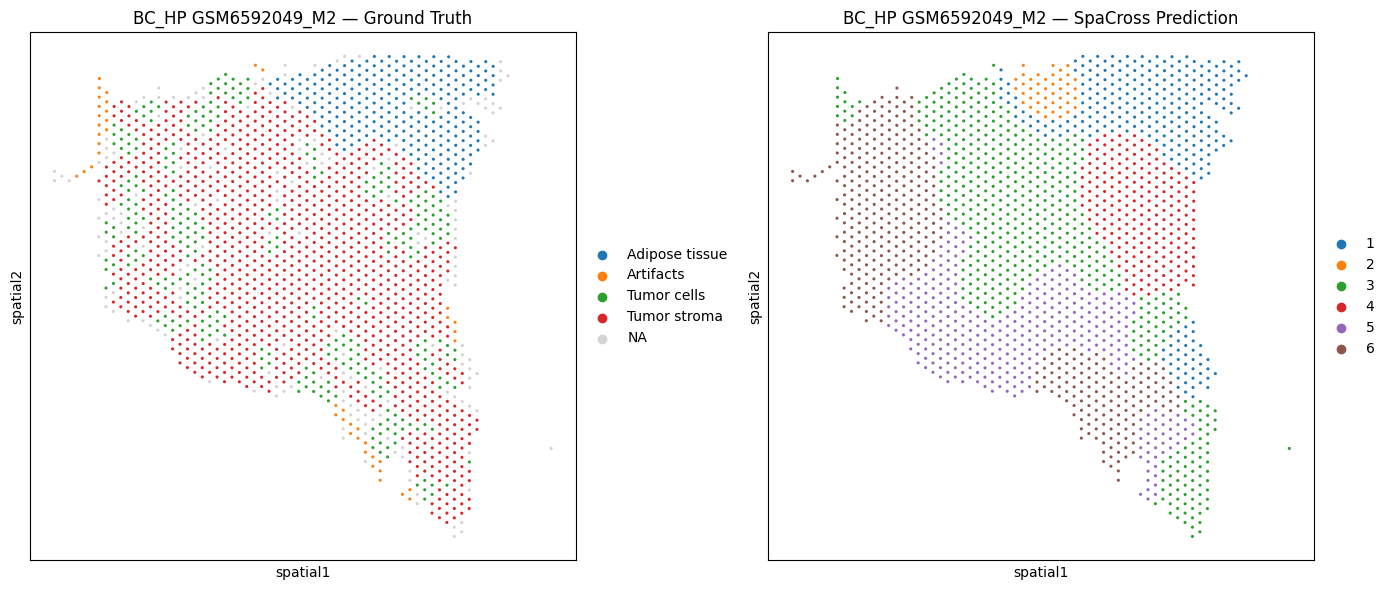

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/BC_HP_10x/data")
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/bc_hp_spacross")

SAMPLE_ID = "GSM6592049_M2"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

predictions["sample"] = predictions["sample"].astype(str)
pred_slice = predictions[predictions["sample"] == str(SAMPLE_ID)].copy()

if pred_slice.empty:
    available = sorted(predictions["sample"].unique())
    raise ValueError(
        f"No predictions found for sample {SAMPLE_ID}. "
        f"Available samples: {available}"
    )

pred_slice = pred_slice.set_index("spot_id")

adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")
adata.var_names_make_unique()

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

if "spatial" not in adata.obsm:
    if "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
    else:
        raise KeyError(f"No spatial coordinates found. obsm keys = {list(adata.obsm.keys())}")

print(f"SAMPLE_ID = {SAMPLE_ID}")
print(f"n spots in adata      : {adata.n_obs}")
print(f"n predictions matched : {pred_slice.index.isin(adata.obs_names).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="true_label",
    ax=axes[0],
    show=False,
    title=f"BC_HP {SAMPLE_ID} — Ground Truth",
    s=20,
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="pred_label",
    ax=axes[1],
    show=False,
    title=f"BC_HP {SAMPLE_ID} — SpaCross Prediction",
    s=20,
)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# Running results summary

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/bc_hp_spacross")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)

performance["sample"] = performance["sample"].astype(str)
performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "dataset", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "clust_method", "gpu_model",
]

display_cols = [c for c in display_cols if c in performance.columns]

print("===== All BC_HP SpaCross results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary_cols = [c for c in ["ARI", "NMI", "ACC", "DIS", "running_time_sec"] if c in performance.columns]
display(performance[summary_cols].describe())

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All BC_HP SpaCross results =====


,dataset,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,clust_method,gpu_model
0,BC_HP_10x,GSM6592049_M2,0,0.162043,0.251059,0.262103,0.052356,6,1848,1672,9.32,mclust,NVIDIA A30
1,BC_HP_10x,GSM6592050_M3,0,0.079975,0.105560,0.108705,0.055573,6,2417,2045,11.41,mclust,NVIDIA A30
2,BC_HP_10x,GSM6592051_M4,0,0.424141,0.512074,0.512100,0.063238,6,1564,932,8.10,mclust,NVIDIA A30
3,BC_HP_10x,GSM6592052_M5,0,0.165423,0.237015,0.241326,0.053306,6,2104,1684,12.03,mclust,NVIDIA A30
4,BC_HP_10x,GSM6592053_M6,0,0.133110,0.202654,0.214083,0.058594,6,1731,1429,9.70,mclust,NVIDIA A30
5,BC_HP_10x,GSM6592054_M7,0,0.068649,0.181319,0.183936,0.046453,6,1596,1390,16.81,mclust,NVIDIA A30
6,BC_HP_10x,GSM6592055_M8,0,0.106803,0.175698,0.176712,0.069917,6,1055,763,6.77,mclust,NVIDIA A30
7,BC_HP_10x,GSM6592056_M9,0,0.018429,0.079997,0.085700,0.051811,6,1258,1064,14.50,mclust,NVIDIA A30
8,BC_HP_10x,GSM6592057_M10,0,0.027062,0.083169,0.090706,0.119531,6,370,167,9.06,mclust,NVIDIA A30
9,BC_HP_10x,GSM6592058_M11,0,0.048496,0.164766,0.167248,0.045784,6,1405,1118,18.38,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,14.000000,14.000000,14.000000,14.000000,14.000000
mean,0.116088,0.188088,0.194849,0.057274,12.212143
std,0.106328,0.121046,0.119615,0.019486,3.736428
min,0.018429,0.026042,0.030059,0.042621,6.770000
25%,0.050930,0.112827,0.122268,0.046657,9.125000
50%,0.082701,0.170232,0.171980,0.052334,11.720000
75%,0.154810,0.228424,0.234515,0.057839,14.922500
max,0.424141,0.512074,0.512100,0.119531,18.380000



===== Mean metrics =====
Mean ARI: 0.1161
Mean NMI: 0.1881
Mean ACC: 0.1948
Mean DIS: 0.0573

===== Best / worst ARI =====
Best ARI : GSM6592051_M4  ARI=0.4241
Worst ARI: GSM6592056_M9  ARI=0.0184


# actual layer in ground truth checking

In [28]:
import scanpy as sc
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/BC_HP_10x/data")

ALL_BC_HP_SAMPLES = [
    "GSM6592049_M2",
    "GSM6592050_M3",
    "GSM6592051_M4",
    "GSM6592052_M5",
    "GSM6592053_M6",
    "GSM6592055_M8",
    "GSM6592059_M13",
    "GSM6592060_M14",
    "GSM6592061_M15",
    "GSM6592062_M16",
    "GSM6592054_M7",
    "GSM6592057_M10",
    "GSM6592056_M9",
    "GSM6592058_M11",
]

results = []

for sample_id in ALL_BC_HP_SAMPLES:
    path = DATA_ROOT / f"SCE_{sample_id}.h5ad"

    if not path.exists():
        print(f"[MISSING] {sample_id}")
        continue

    adata = sc.read_h5ad(path)

    if "z" not in adata.obs:
        print(f"[NO LABEL] {sample_id}")
        continue

    labels_all = adata.obs["z"]

    # 去掉 NaN
    labels = labels_all.dropna()

    unique_labels = sorted(labels.unique())
    n_classes = len(unique_labels)

    results.append({
        "sample": sample_id,
        "n_classes": n_classes,
        "labels": unique_labels,
        "n_spots": adata.n_obs,
        "n_labeled": len(labels),
        "n_NA": int(labels_all.isna().sum()),
    })

# 转成 dataframe
df = pd.DataFrame(results).sort_values("n_classes")

print("===== BC_HP_10x: Per-sample class counts =====")
display(df)

print("\n===== Summary =====")
print(df["n_classes"].value_counts().sort_index())

print("\n===== Samples with only 1 class =====")
print(df[df["n_classes"] == 1]["sample"].tolist())

print("\n===== Suggested dictionary: sample -> n_classes =====")
cluster_dict = dict(zip(df["sample"], df["n_classes"]))
print(cluster_dict)

===== BC_HP_10x: Per-sample class counts =====


,sample,n_classes,labels,n_spots,n_labeled,n_NA
6,GSM6592059_M13,2,"[Artifacts, Tumor cells]",2657,1760,897
11,GSM6592057_M10,2,"[Fibrosis, Normal epithelium]",370,167,203
4,GSM6592053_M6,3,"[Artifacts, Tumor cells, Tumor stroma]",1731,1429,302
1,GSM6592050_M3,3,"[Artifacts, Tumor cells, Tumor stroma]",2417,2045,372
8,GSM6592061_M15,3,"[Artifacts, Endothelial, Tumor cells]",3037,2856,181
3,GSM6592052_M5,3,"[Fibrosis, High TILs stroma, Tumor cells]",2104,1684,420
5,GSM6592055_M8,4,"[Adipose tissue, Fibrous stroma, In situ carci...",1055,763,292
0,GSM6592049_M2,4,"[Adipose tissue, Artifacts, Tumor cells, Tumor...",1848,1672,176
12,GSM6592056_M9,4,"[Adipose tissue, Fibrosis, Lymphocytes, Normal...",1258,1064,194
2,GSM6592051_M4,5,"[Adipose tissue, Artifacts, Fibrosis, Tumor ce...",1564,932,632



===== Summary =====
n_classes
2    2
3    4
4    3
5    4
6    1
Name: count, dtype: int64

===== Samples with only 1 class =====
[]

===== Suggested dictionary: sample -> n_classes =====
{'GSM6592059_M13': 2, 'GSM6592057_M10': 2, 'GSM6592053_M6': 3, 'GSM6592050_M3': 3, 'GSM6592061_M15': 3, 'GSM6592052_M5': 3, 'GSM6592055_M8': 4, 'GSM6592049_M2': 4, 'GSM6592056_M9': 4, 'GSM6592051_M4': 5, 'GSM6592060_M14': 5, 'GSM6592062_M16': 5, 'GSM6592058_M11': 5, 'GSM6592054_M7': 6}
